<a href="https://colab.research.google.com/github/IrineuBovoJunior398/P-S_GRADUA-O_IA_UTFPR/blob/main/C%C3%B3pia_de_R_EXERCISE_DUAS_BOLAS_VERMELHAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Combinações possíveis de posições das duas bolas vermelhas:
Posições (0, 1): R R W W W W
Posições (0, 2): R W R W W W
Posições (0, 3): R W W R W W
Posições (0, 4): R W W W R W
Posições (0, 5): R W W W W R
Posições (1, 2): W R R W W W
Posições (1, 3): W R W R W W
Posições (1, 4): W R W W R W
Posições (1, 5): W R W W W R
Posições (2, 3): W W R R W W
Posições (2, 4): W W R W R W
Posições (2, 5): W W R W W R
Posições (3, 4): W W W R R W
Posições (3, 5): W W W R W R
Posições (4, 5): W W W W R R


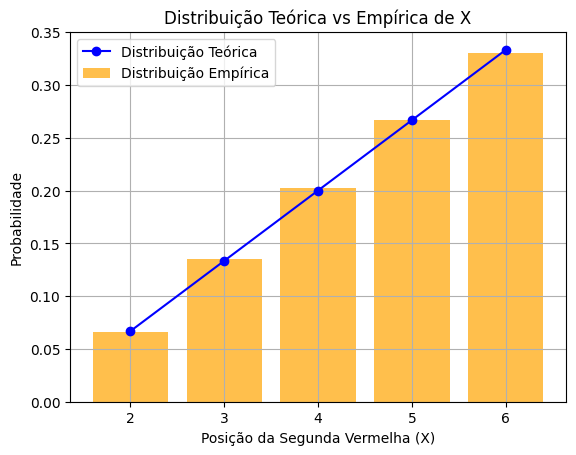


Tabela de Probabilidades:
   k  Probabilidade Teórica  Probabilidade Empírica
0  2               0.066667                 0.06633
1  3               0.133333                 0.13473
2  4               0.200000                 0.20205
3  5               0.266667                 0.26633
4  6               0.333333                 0.33056


In [ ]:
import numpy as np
import itertools
import random
import matplotlib.pyplot as plt
import pandas as pd

# Etapa 1: Listar visualmente todas as 15 combinações possíveis de posições das duas bolas vermelhas entre 6 retiradas
# Usamos itertools.combinations para gerar todas as combinações de 2 posições de 6 para as vermelhas
print("Combinações possíveis de posições das duas bolas vermelhas:")
for combo in itertools.combinations(range(6), 2):
    # Criamos uma lista de 6 posições: 'R' nas posições escolhidas, 'W' nas outras
    bolas = ['W'] * 6
    for pos in combo:
        bolas[pos] = 'R'
    # Imprimimos a combinação como string
    print(f"Posições {combo}: {' '.join(bolas)}")

# Etapa 2: Simular 100000 experimentos de retirada de 6 bolas (2 vermelhas e 4 brancas), sem reposição
# Registramos a posição da segunda vermelha (1-based)
num_simulacoes = 100000
contagem_x = {k: 0 for k in range(2, 7)}  # k de 2 a 6
for _ in range(num_simulacoes):
    # Criamos a urna com 2 'R' e 4 'W'
    bolas = ['R', 'R', 'W', 'W', 'W', 'W']
    # Embaralhamos sem reposição
    random.shuffle(bolas)
    # Encontramos as posições das 'R' (0-based)
    posicoes_r = [i for i, b in enumerate(bolas) if b == 'R']
    # A segunda vermelha é a segunda posição (1-based)
    segunda_r_pos = posicoes_r[1] + 1
    # Incrementamos a contagem
    contagem_x[segunda_r_pos] += 1

# Etapa 3: Estimar empiricamente f(X), onde X é a posição da segunda vermelha
# Calculamos as probabilidades empíricas dividindo as contagens pelo número de simulações
prob_empirica = {k: contagem_x[k] / num_simulacoes for k in range(2, 7)}

# Etapa 4: Plotar a distribuição real teórica e a empírica usando matplotlib
# Probabilidades teóricas: P(X=k) = (k-1)/15 para k=2 a 6
prob_teorica = {k: (k-1)/15 for k in range(2, 7)}

# Valores para o eixo x
k_values = list(range(2, 7))

# Plot da distribuição teórica (linha)
plt.plot(k_values, [prob_teorica[k] for k in k_values], label='Distribuição Teórica', marker='o', color='blue')

# Plot da distribuição empírica (barras)
plt.bar(k_values, [prob_empirica[k] for k in k_values], alpha=0.7, label='Distribuição Empírica', color='orange')

# Configurações do gráfico
plt.xlabel('Posição da Segunda Vermelha (X)')
plt.ylabel('Probabilidade')
plt.title('Distribuição Teórica vs Empírica de X')
plt.legend()
plt.grid(True)

# Mostrar o gráfico
plt.show()

# Etapa 5: Gerar e imprimir uma tabela de probabilidade com pandas
# Criamos um DataFrame com k, probabilidade teórica e empírica
df = pd.DataFrame({
    'k': k_values,
    'Probabilidade Teórica': [prob_teorica[k] for k in k_values],
    'Probabilidade Empírica': [prob_empirica[k] for k in k_values]
})

# Imprimimos a tabela
print("\nTabela de Probabilidades:")
print(df)